# Modelos no lineales mediante transformaciones

Análisis de diferentes **transformaciones de variables** para estudiar relaciones no lineales y determinar cuáles permiten obtener un comportamiento aproximadamente lineal.

### Objetivos

- Identificar cuándo un conjunto de datos no presenta una tendencia lineal evidente.
- Aplicar transformaciones sobre las variables para buscar relaciones aproximadamente lineales.
- Utilizar mínimos cuadrados sobre los datos transformados.
- Comparar las transformaciones mediante el coeficiente de determinación $R^2$.
- Relacionar una transformación linealizada con la forma de un posible modelo no lineal.

**Tecnologías:** Python · NumPy · Matplotlib

## 1. Datos del problema

Se consideran observaciones históricas sobre la producción comercial de especies marinas en Chesapeake Bay.

El conjunto original contiene información de pez azul y cangrejo azul; en este notebook se analiza únicamente la **producción de pez azul**, ya que es la serie utilizada por los códigos desarrollados.

| Año | Producción de pez azul (lb) |
|---|---:|
| 1940 | 15 000 |
| 1945 | 150 000 |
| 1950 | 250 000 |
| 1955 | 275 000 |
| 1960 | 270 000 |
| 1965 | 280 000 |
| 1970 | 290 000 |
| 1975 | 650 000 |
| 1980 | 1 200 000 |
| 1985 | 1 500 000 |
| 1990 | 2 750 000 |

El primer paso consiste en observar los datos originales y determinar si una recta parece representar adecuadamente su comportamiento.

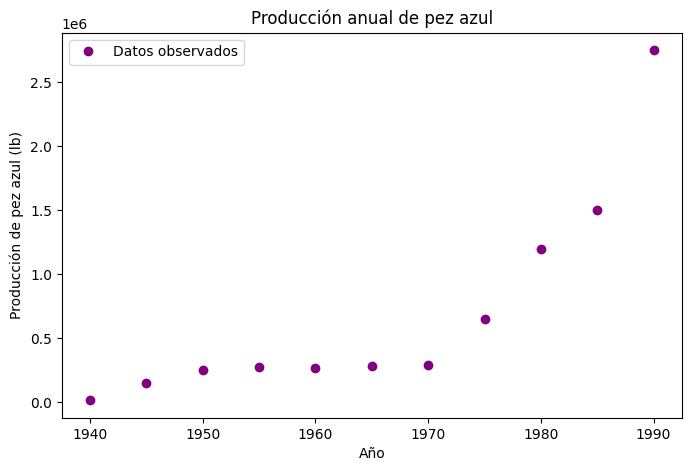

Los datos no tienen tendencia a una linea recta


In [1]:
# Gráfico de dispersión de datos observados (solo datos del pez azul)
import numpy as np
import matplotlib.pyplot as plt

# Datos
x_data = [1940, 1945, 1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990]
y_data = [15000, 150000, 250000, 275000, 270000, 280000, 290000, 650000, 1200000, 1500000, 2750000]

# Gráfica solo con puntos
plt.figure(figsize=(8,5))
plt.plot(x_data, y_data, 'o', color='purple', label='Datos observados')
plt.xlabel("Año")
plt.ylabel("Producción de pez azul (lb)")
plt.title("Producción anual de pez azul")
plt.legend()
plt.show()
print("Los datos no tienen tendencia a una linea recta")

## 2. Linealización de modelos no lineales

Los datos originales no muestran una tendencia claramente lineal. Una estrategia para estudiar este tipo de relaciones consiste en **transformar una o ambas variables** y analizar si los datos transformados presentan un comportamiento más cercano a una recta.

Entre las transformaciones evaluadas se encuentran:

- $\sqrt{y}$
- $1/y$
- $x^2$
- $x^3$
- $\ln(x)$
- $\ln(y)$
- $\sqrt{x}$
- transformación log-log: $\ln(x)$ frente a $\ln(y)$

Para cada transformación se calcula una recta mediante mínimos cuadrados y se utiliza el coeficiente de determinación $R^2$ como medida de qué tan lineal resulta la relación en la escala transformada.

### Coeficiente de determinación $R^2$

Para una recta ajustada a los datos transformados:

$$
R^2 =
1-
\frac{
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}{
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
$$

donde:

- $y_i$ representa el valor observado en la escala analizada;
- $\hat{y}_i$ representa el valor estimado por la recta;
- $\bar{y}$ es la media de los valores observados.

Un valor de $R^2$ más cercano a $1$ indica que la relación transformada presenta un comportamiento más próximo a una recta.

> **Importante:** en este análisis, $R^2$ se calcula en la escala transformada. Por tanto, sirve principalmente para comparar qué transformación produce una relación más lineal; no debe interpretarse automáticamente como el error del modelo en la escala original.

## 3. Comparación gráfica de transformaciones

El siguiente código corresponde al bloque original que:

1. aplica diferentes transformaciones a los datos;
2. calcula la recta de mínimos cuadrados para cada caso;
3. obtiene el valor de $R^2$;
4. representa los datos transformados junto con su ajuste lineal.

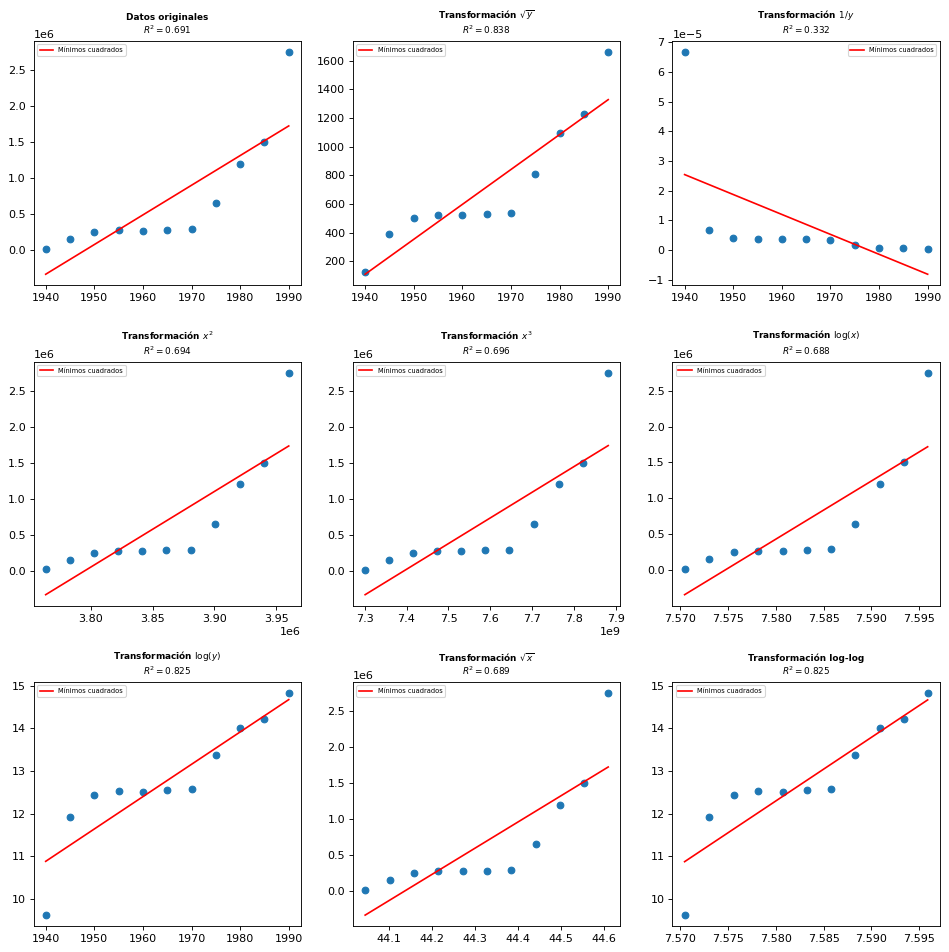

In [1]:
# Transformación del metodo de la clase con R cuadrado y minimos cuadrados
import numpy as np
import matplotlib.pyplot as plt

# Datos de la tabla
x_data = np.array([1940, 1945, 1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990])
y_data = np.array([15000, 150000, 250000, 275000, 270000, 280000, 290000, 650000, 1200000, 1500000, 2750000])

# Función para calcular R^2 (versión corta usando correlación)
def calcular_r2(x, y):
    return np.corrcoef(x, y)[0,1]**2

# Función de mínimos cuadrados (pendiente e intercepto)
def MinimosCuadrados(x_data, y_data):
    x_data = x_data.astype(np.float64)
    y_data = y_data.astype(np.float64)
    n = len(x_data)
    sum_x = np.sum(x_data)
    sum_y = np.sum(y_data)
    sum_yx = np.sum(x_data*y_data)
    sum_x_square = np.sum(x_data**2)
    m = (n*sum_yx - sum_x * sum_y) / (n*sum_x_square - sum_x**2)
    b = (sum_x_square * sum_y - sum_x * sum_yx) / (n*sum_x_square - sum_x**2)
    return m, b

# Función para graficar con la recta de mínimos cuadrados
def plot_transform(ax, x, y, title):
    # Calcular recta
    m, b = MinimosCuadrados(x, y)
    P_linea = lambda x: m*x + b
    # Calcular R^2
    r2 = calcular_r2(x, y)
    # Graficar puntos
    ax.plot(x, y, 'o')
    # Graficar recta ajustada
    x_line = np.linspace(min(x), max(x), 100)
    ax.plot(x_line, P_linea(x_line), 'r-', label='Mínimos cuadrados')
    # Título con R^2
    ax.set_title(f"{title}\n$R^2={r2:.3f}$", fontsize=8, fontweight='bold')
    ax.legend(fontsize=6)

def GraficasTransformacion(x_data, y_data):
    fig, axs = plt.subplots(3, 3, figsize=(12,12), dpi=80)

    # 1. Datos originales
    plot_transform(axs[0,0], x_data, y_data, "Datos originales")

    # 2. x vs sqrt(y)
    plot_transform(axs[0,1], x_data, np.sqrt(y_data), "Transformación $\\sqrt{y}$")

    # 3. x vs 1/y
    plot_transform(axs[0,2], x_data, 1/y_data, "Transformación $1/y$")

    # 4. x^2 vs y
    plot_transform(axs[1,0], x_data**2, y_data, "Transformación $x^2$")

    # 5. x^3 vs y
    plot_transform(axs[1,1], x_data**3, y_data, "Transformación $x^3$")

    # 6. log(x) vs y
    plot_transform(axs[1,2], np.log(x_data), y_data, "Transformación $\\log(x)$")

    # 7. x vs log(y)
    plot_transform(axs[2,0], x_data, np.log(y_data), "Transformación $\\log(y)$")

    # 8. sqrt(x) vs y
    plot_transform(axs[2,1], np.sqrt(x_data), y_data, "Transformación $\\sqrt{x}$")

    # 9. log(x) vs log(y)
    plot_transform(axs[2,2], np.log(x_data), np.log(y_data), "Transformación log-log")

    plt.tight_layout()
    plt.show()

GraficasTransformacion(x_data, y_data)

## 4. Análisis de los resultados

A partir de las transformaciones evaluadas se obtienen aproximadamente los siguientes valores de $R^2$:

| Transformación | $R^2$ aproximado |
|---|---:|
| $x$ vs. $\sqrt{y}$ | **0.838** |
| $\ln(x)$ vs. $\ln(y)$ | **0.825** |
| $x$ vs. $\ln(y)$ | **0.825** |
| $x^3$ vs. $y$ | 0.696 |
| $x^2$ vs. $y$ | 0.694 |
| Datos originales | 0.691 |
| $\sqrt{x}$ vs. $y$ | 0.689 |
| $\ln(x)$ vs. $y$ | 0.688 |
| $x$ vs. $1/y$ | 0.332 |

De acuerdo con este criterio, las transformaciones que producen una relación más cercana a una recta son:

1. $x$ frente a $\sqrt{y}$;
2. $\ln(x)$ frente a $\ln(y)$;
3. $x$ frente a $\ln(y)$.

En cambio, la transformación $x$ frente a $1/y$ presenta el menor $R^2$ de los casos analizados y no resulta favorable para estos datos.

## 5. Relación entre las transformaciones y los modelos no lineales

Una vez encontrada una transformación que se comporta aproximadamente de forma lineal, la ecuación ajustada puede volver a expresarse en la escala original.

| Transformación linealizada | Ecuación en escala transformada | Forma del modelo original |
|---|---|---|
| $x$ vs. $\sqrt{y}$ | $\sqrt{y}=mx+b$ | $y=(mx+b)^2$ |
| $x$ vs. $1/y$ | $\frac{1}{y}=mx+b$ | $y=\frac{1}{mx+b}$ |
| $x^2$ vs. $y$ | $y=m x^2+b$ | $y=m x^2+b$ |
| $x^3$ vs. $y$ | $y=m x^3+b$ | $y=m x^3+b$ |
| $\ln(x)$ vs. $y$ | $y=m\ln(x)+b$ | $y=m\ln(x)+b$ |
| $x$ vs. $\ln(y)$ | $\ln(y)=mx+b$ | $y=e^{mx+b}$ |
| $\sqrt{x}$ vs. $y$ | $y=m\sqrt{x}+b$ | $y=m\sqrt{x}+b$ |
| $\ln(x)$ vs. $\ln(y)$ | $\ln(y)=m\ln(x)+b$ | $y=e^b x^m$ |

Esto permite utilizar herramientas de ajuste lineal sobre datos transformados para estudiar distintos tipos de relaciones no lineales.

## 6. Conclusiones

A partir del análisis realizado se puede concluir que:

- Los datos originales de producción de pez azul no presentan una tendencia lineal evidente.
- Las transformaciones permiten estudiar relaciones no lineales mediante herramientas de ajuste lineal.
- El coeficiente $R^2$ facilita la comparación de la linealidad obtenida después de cada transformación.
- Para estos datos, las transformaciones con mejor comportamiento lineal son $x$ vs. $\sqrt{y}$, log-log y $x$ vs. $\ln(y)$.
- Una transformación adecuada puede relacionarse posteriormente con una forma funcional no lineal en la escala original.
- Un valor alto de $R^2$ en la escala transformada debe interpretarse junto con la gráfica y con la forma del modelo, no de manera aislada.
- La selección del modelo debe considerar tanto el ajuste numérico como la coherencia de su comportamiento respecto a los datos observados.